In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
import pandas as pd
import seaborn as sns

In [3]:
stdscale = StandardScaler()

In [4]:
time_hour = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]

active_users = [
110,95,85,80,75,90,
180,320,480,600,650,700,
750,720,680,620,580,650,
820,900,950,780,500,250
]

internet_speed = [
98,101,104,106,108,102,
92,78,65,55,52,50,
48,49,51,54,58,53,
42,38,35,45,63,84
]

In [7]:
df = pd.DataFrame({
    "time_hour": time_hour,
    "active_users": active_users,
    "internet_speed": internet_speed
})

In [8]:
X = df[['time_hour', 'active_users']]

In [9]:
X_scaled = stdscale.fit_transform(X)

In [10]:
print(X_scaled)

[[-1.66132477 -1.29975813]
 [-1.51686175 -1.35160444]
 [-1.37239873 -1.38616864]
 [-1.2279357  -1.40345075]
 [-1.08347268 -1.42073285]
 [-0.93900965 -1.36888654]
 [-0.79454663 -1.05780869]
 [-0.65008361 -0.57390982]
 [-0.50562058 -0.02088254]
 [-0.36115756  0.39388792]
 [-0.21669454  0.56670895]
 [-0.07223151  0.73952997]
 [ 0.07223151  0.912351  ]
 [ 0.21669454  0.80865838]
 [ 0.36115756  0.67040156]
 [ 0.50562058  0.46301633]
 [ 0.65008361  0.32475951]
 [ 0.79454663  0.56670895]
 [ 0.93900965  1.15430043]
 [ 1.08347268  1.43081408]
 [ 1.2279357   1.6036351 ]
 [ 1.37239873  1.01604361]
 [ 1.51686175  0.04824587]
 [ 1.66132477 -0.81585926]]


<Axes: >

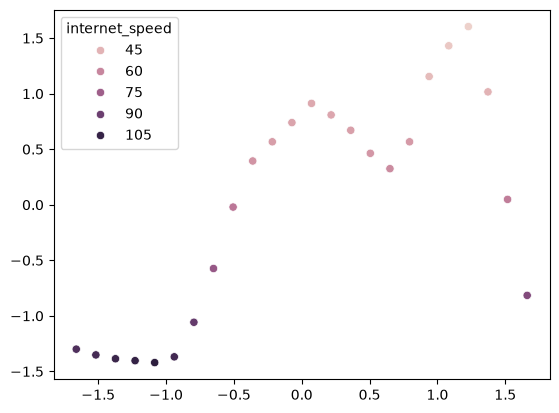

In [13]:
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=df['internet_speed'])

In [17]:
reg_obj = linear_model.LinearRegression()

In [18]:
reg_obj.fit(X_scaled, df['internet_speed'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ -0.93,-23.25]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,67.96
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[6.45,2.52]"


In [23]:
scaled_X_for_prediction = stdscale.transform([[22,750]])
print(scaled_X_for_prediction)

[[1.51686175 0.912351  ]]


C:\Users\aniru\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
predicted_speed = reg_obj.predict([scaled_X_for_prediction[0]])

In [22]:
print('predicted speed: ', predicted_speed)

predicted speed:  [45.32842582]
